# Day 12: Pharmacy Stock Alert System

**Industry:** Healthcare  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · matplotlib · seaborn · API data · datetime · alerting

**Data:** FDA Drug Shortage Database — 1,693 real active and resolved drug shortages  
Source: api.fda.gov (official US FDA open data, no login required)

---

## Who uses this
A **pharmacy manager** doing their daily stock review. Instead of manually checking the FDA shortage database and cross-referencing with internal stock levels, this notebook pulls live FDA data, flags critical shortages by category, and outputs a prioritised alert list ready to act on.

## Problem
Medicine stockouts cause patient harm — clinicians prescribe drugs that aren't available, pharmacists scramble for alternatives under time pressure. The FDA publishes shortage data daily but most pharmacies don't have a systematic way to monitor it. This notebook automates that monitoring.

## What we build
1. Pull live FDA drug shortage data via API
2. Parse and clean the JSON response
3. Classify shortages by severity and drug category
4. Calculate shortage duration (how long has each drug been short?)
5. Generate a prioritised alert list
6. Visualise shortage patterns
7. Export actionable CSV reports

## Step 1 — Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import os
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Pull Live FDA Drug Shortage Data

We fetch from the FDA open API — no API key required. We pull all available records in batches of 1000.

In [10]:
BASE_URL = 'https://api.fda.gov/drug/shortages.json'

def fetch_fda_shortages(limit=1000, skip=0):
    """Fetch drug shortage records from FDA API."""
    params = {'limit': limit, 'skip': skip}
    r = requests.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

# Fetch first batch
print('Fetching FDA drug shortage data...')
data = fetch_fda_shortages(limit=1000, skip=0)
total = data['meta']['results']['total']
records = data['results']

# Fetch second batch if more records exist
if total > 1000:
    data2 = fetch_fda_shortages(limit=min(1000, total-1000), skip=1000)
    records.extend(data2['results'])

print(f'Total records available: {total:,}')
print(f'Records fetched:         {len(records):,}')
print(f'Last updated:            {data["meta"]["last_updated"]}')

Fetching FDA drug shortage data...


Total records available: 1,693
Records fetched:         1,693
Last updated:            2026-04-04


## Step 3 — Parse JSON into DataFrame

The FDA response is nested JSON. We extract the fields we need and flatten into a clean DataFrame.

In [11]:
def parse_record(rec):
    """Extract key fields from a single FDA shortage record."""
    openfda = rec.get('openfda', {})
    return {
        'generic_name':       rec.get('generic_name', ''),
        'brand_name':         ', '.join(openfda.get('brand_name', [])),
        'manufacturer':       ', '.join(openfda.get('manufacturer_name', [])),
        'availability':       rec.get('availability', ''),
        'initial_posting_date': rec.get('initial_posting_date', ''),
        'update_type':        rec.get('update_type', ''),
        'route':              ', '.join(openfda.get('route', [])),
        'product_type':       ', '.join(openfda.get('product_type', [])),
        'substance_name':     ', '.join(openfda.get('substance_name', [])),
        'package_ndc':        rec.get('package_ndc', ''),
    }

rows = [parse_record(r) for r in records]
df = pd.DataFrame(rows)

print(f'Shape: {df.shape}')
print(f'\nAvailability breakdown:')
print(df['availability'].value_counts().to_string())
print(f'\nUpdate type breakdown:')
print(df['update_type'].value_counts().to_string())
df.head(3)

Shape: (1693, 10)

Availability breakdown:
availability
Available               742
                        547
Unavailable             286
Limited Availability    111
Limited Availablity       3
Information pending       2
Limited Availabiltiy      1
Avaliable                 1

Update type breakdown:
update_type
Reverified    812
New           521
Revised       360


,generic_name,brand_name,manufacturer,availability,initial_posting_date,update_type,route,product_type,substance_name,package_ndc
0,Ropivacaine Hydrochloride Injection,NAROPIN,"Fresenius Kabi USA, LLC",Available,03/23/2018,Reverified,"EPIDURAL, INFILTRATION, PERINEURAL",HUMAN PRESCRIPTION DRUG,ROPIVACAINE HYDROCHLORIDE,63323-286-00
1,"Amphetamine Aspartate Monohydrate, Amphetamine...","DEXTROAMPHETAMINE SACCHARATE, AMPHETAMINE ASPA...","Elite Laboratories, Inc.",Limited Availability,08/15/2023,Reverified,ORAL,HUMAN PRESCRIPTION DRUG,"AMPHETAMINE ASPARTATE MONOHYDRATE, AMPHETAMINE...",64850-506-01
2,Pilocarpine Hydrochloride Ophthalmic Solution,VUITY,AbbVie Inc.,,03/24/2026,New,OPHTHALMIC,HUMAN PRESCRIPTION DRUG,PILOCARPINE HYDROCHLORIDE,0074-7098-06


## Step 4 — Clean and Enrich

- Parse posting date and calculate shortage duration in days
- Classify drugs into therapeutic categories
- Assign severity based on availability status and duration
- Flag currently active shortages

In [12]:
today = datetime.today()

# Parse date and calculate duration
df['posting_date'] = pd.to_datetime(df['initial_posting_date'], format='%m/%d/%Y', errors='coerce')
df['days_in_shortage'] = (today - df['posting_date']).dt.days
df['year_posted'] = df['posting_date'].dt.year

# Flag active shortages
active_statuses = ['Unavailable', 'Available', 'To Be Discontinued', 'Increased Demand']
df['is_active'] = df['availability'].isin(active_statuses).astype(int)
df['is_unavailable'] = (df['availability'] == 'Unavailable').astype(int)

# Drug category classification based on generic name keywords
def classify_category(name):
    name = str(name).upper()
    if any(k in name for k in ['CILLIN', 'MYCIN', 'CYCLINE', 'FLOXACIN', 'AZITHRO', 'CEPHALEXIN', 'VANCOMYCIN', 'CLINDAMYCIN', 'DOXYCYCLINE', 'TRIMETHOPRIM', 'METRONIDAZOLE']):
        return 'Antibiotics'
    elif any(k in name for k in ['INSULIN', 'METFORMIN', 'GLIPIZIDE', 'GLIMEPIRIDE', 'SITAGLIPTIN', 'EMPAGLIFLOZIN', 'LIRAGLUTIDE', 'SEMAGLUTIDE']):
        return 'Diabetes'
    elif any(k in name for k in ['MORPHINE', 'OXYCODONE', 'HYDROCODONE', 'FENTANYL', 'BUPRENORPHINE', 'NALOXONE', 'TRAMADOL', 'CODEINE', 'HYDROMORPHONE']):
        return 'Pain/Opioids'
    elif any(k in name for k in ['ATORVASTATIN', 'SIMVASTATIN', 'ROSUVASTATIN', 'LISINOPRIL', 'AMLODIPINE', 'METOPROLOL', 'CARVEDILOL', 'LOSARTAN', 'WARFARIN', 'DIGOXIN', 'AMIODARONE', 'HEPARIN', 'EPINEPHRINE', 'NOREPINEPHRINE', 'DOPAMINE', 'VASOPRESSIN']):
        return 'Cardiovascular'
    elif any(k in name for k in ['CARBOPLATIN', 'CISPLATIN', 'FLUOROURACIL', 'METHOTREXATE', 'VINCRISTINE', 'PACLITAXEL', 'DOXORUBICIN', 'CYCLOPHOSPHAMIDE', 'RITUXIMAB', 'LEUCOVORIN', 'IRINOTECAN', 'OXALIPLATIN']):
        return 'Oncology'
    elif any(k in name for k in ['ALBUTEROL', 'BUDESONIDE', 'FLUTICASONE', 'MONTELUKAST', 'IPRATROPIUM', 'TIOTROPIUM', 'SALMETEROL', 'FORMOTEROL', 'THEOPHYLLINE']):
        return 'Respiratory'
    elif any(k in name for k in ['LORAZEPAM', 'DIAZEPAM', 'MIDAZOLAM', 'PROPOFOL', 'KETAMINE', 'ETOMIDATE', 'DEXMEDETOMIDINE', 'SUCCINYLCHOLINE', 'VECURONIUM', 'ROCURONIUM']):
        return 'Sedatives/Anesthesia'
    elif any(k in name for k in ['SALINE', 'DEXTROSE', 'LACTATED', 'SODIUM CHLORIDE', 'POTASSIUM CHLORIDE', 'MAGNESIUM SULFATE', 'CALCIUM GLUCONATE', 'ALBUMIN', 'SODIUM BICARBONATE']):
        return 'IV Fluids'
    elif any(k in name for k in ['ATROPINE', 'NEOSTIGMINE', 'PHYSOSTIGMINE', 'PYRIDOSTIGMINE']):
        return 'Anticholinergics'
    elif any(k in name for k in ['HYDROCORTISONE', 'METHYLPREDNISOLONE', 'DEXAMETHASONE', 'PREDNISONE', 'PREDNISOLONE', 'BETAMETHASONE']):
        return 'Steroids'
    elif any(k in name for k in ['HALOPERIDOL', 'RISPERIDONE', 'OLANZAPINE', 'QUETIAPINE', 'ARIPIPRAZOLE', 'SERTRALINE', 'FLUOXETINE', 'ESCITALOPRAM', 'LITHIUM']):
        return 'Psychiatric'
    elif any(k in name for k in ['PHENYTOIN', 'LEVETIRACETAM', 'VALPROIC', 'CARBAMAZEPINE', 'LAMOTRIGINE', 'GABAPENTIN', 'TOPIRAMATE']):
        return 'Neurology'
    elif any(k in name for k in ['FUROSEMIDE', 'HYDROCHLOROTHIAZIDE', 'SPIRONOLACTONE', 'MANNITOL', 'ACETAZOLAMIDE']):
        return 'Diuretics'
    elif any(k in name for k in ['ONDANSETRON', 'METOCLOPRAMIDE', 'PROMETHAZINE', 'PROCHLORPERAZINE', 'PANTOPRAZOLE', 'OMEPRAZOLE', 'FAMOTIDINE']):
        return 'GI/Antiemetics'
    elif any(k in name for k in ['ACETAMINOPHEN', 'IBUPROFEN', 'KETOROLAC', 'NAPROXEN', 'INDOMETHACIN']):
        return 'Analgesics/NSAIDs'
    else:
        return 'Other'

df['category'] = df['generic_name'].apply(classify_category)

# Severity scoring
def severity(row):
    if row['availability'] == 'Unavailable':
        return 'Critical'
    elif row['availability'] == 'To Be Discontinued':
        return 'High'
    elif row['days_in_shortage'] > 365:
        return 'High'
    elif row['days_in_shortage'] > 90:
        return 'Medium'
    else:
        return 'Low'

df['severity'] = df.apply(severity, axis=1)

print(f'Total records:       {len(df):,}')
print(f'Active shortages:    {df["is_active"].sum():,}')
print(f'Unavailable drugs:   {df["is_unavailable"].sum():,}')
print(f'Avg shortage duration: {df["days_in_shortage"].mean():.0f} days')
print(f'\nSeverity breakdown:')
print(df['severity'].value_counts().to_string())
print(f'\nCategory breakdown:')
print(df['category'].value_counts().to_string())

Total records:       1,693
Active shortages:    1,028
Unavailable drugs:   286
Avg shortage duration: 1480 days

Severity breakdown:
severity
High        890
Medium      413
Critical    286
Low         104

Category breakdown:
category
Other                   949
Sedatives/Anesthesia    140
IV Fluids               102
Cardiovascular           93
Pain/Opioids             80
Oncology                 62
Antibiotics              61
Diuretics                48
Steroids                 47
Analgesics/NSAIDs        25
Diabetes                 22
GI/Antiemetics           20
Anticholinergics         19
Neurology                11
Respiratory               8
Psychiatric               6


## Step 5 — Generate Priority Alert List

The alert list ranks drugs by urgency — Critical first, then High, then by duration. This is what a pharmacy manager would review each morning.

In [13]:
severity_order = {'Critical': 0, 'High': 1, 'Medium': 2, 'Low': 3}
df['severity_rank'] = df['severity'].map(severity_order)

alert_list = (
    df[df['is_active'] == 1]
    .sort_values(['severity_rank', 'days_in_shortage'], ascending=[True, False])
    [['generic_name', 'brand_name', 'manufacturer', 'category',
      'availability', 'severity', 'days_in_shortage', 'posting_date', 'route']]
    .reset_index(drop=True)
)

print(f'Active shortage alert list: {len(alert_list):,} drugs')
print(f'\nCritical alerts:')
critical = alert_list[alert_list['severity'] == 'Critical']
print(critical[['generic_name','category','days_in_shortage','manufacturer']].head(15).to_string())
print(f'\nHigh severity alerts (top 10):')
high = alert_list[alert_list['severity'] == 'High']
print(high[['generic_name','category','days_in_shortage','availability']].head(10).to_string())

Active shortage alert list: 1,028 drugs

Critical alerts:
                                                 generic_name          category  days_in_shortage             manufacturer
0                                  Fentanyl Citrate Injection      Pain/Opioids              5207  Fresenius Kabi USA, LLC
1                                  Atropine Sulfate Injection  Anticholinergics              5207                         
2                                  Atropine Sulfate Injection  Anticholinergics              5207            Hospira, Inc.
3                                  Atropine Sulfate Injection  Anticholinergics              5207                         
4                                  Atropine Sulfate Injection  Anticholinergics              5207   Accord Healthcare Inc.
5                                  Fentanyl Citrate Injection      Pain/Opioids              5207  Fresenius Kabi USA, LLC
6                                  Fentanyl Citrate Injection      Pain/Opioids  

## Step 6 — Analysis by Category and Duration

In [14]:
# Shortage count by category
by_category = (
    df.groupby('category')
    .agg(
        total=('generic_name', 'count'),
        unavailable=('is_unavailable', 'sum'),
        avg_duration=('days_in_shortage', 'mean'),
        critical=('severity', lambda x: (x == 'Critical').sum()),
        high=('severity', lambda x: (x == 'High').sum())
    )
    .round(0)
    .sort_values('total', ascending=False)
)

# Shortage trend by year posted
by_year = (
    df.dropna(subset=['year_posted'])
    .groupby('year_posted')
    .agg(
        total=('generic_name', 'count'),
        unavailable=('is_unavailable', 'sum')
    )
    .reset_index()
    .query('year_posted >= 2018')
)

# Longest running shortages
longest = (
    df.sort_values('days_in_shortage', ascending=False)
    [['generic_name', 'category', 'days_in_shortage', 'availability', 'manufacturer']]
    .head(10)
)

print('=== Shortages by therapeutic category ===')
print(by_category.to_string())
print('\n=== Top 10 longest running shortages ===')
print(longest.to_string())

=== Shortages by therapeutic category ===
                      total  unavailable  avg_duration  critical  high
category                                                              
Other                   949          126        1308.0       126   490
Sedatives/Anesthesia    140           34        1888.0        34   104
IV Fluids               102           11        1352.0        11    61
Cardiovascular           93           18        2393.0        18    44
Pain/Opioids             80           32        2670.0        32    35
Oncology                 62            8         778.0         8    33
Antibiotics              61            8         623.0         8    20
Diuretics                48           18        1669.0        18    24
Steroids                 47            7        1843.0         7    40
Analgesics/NSAIDs        25           11        2912.0        11    14
Diabetes                 22            0         540.0         0     9
GI/Antiemetics           20        

## Step 7 — Visualise: 4-Panel Dashboard

Dashboard saved as shortage_analysis.png


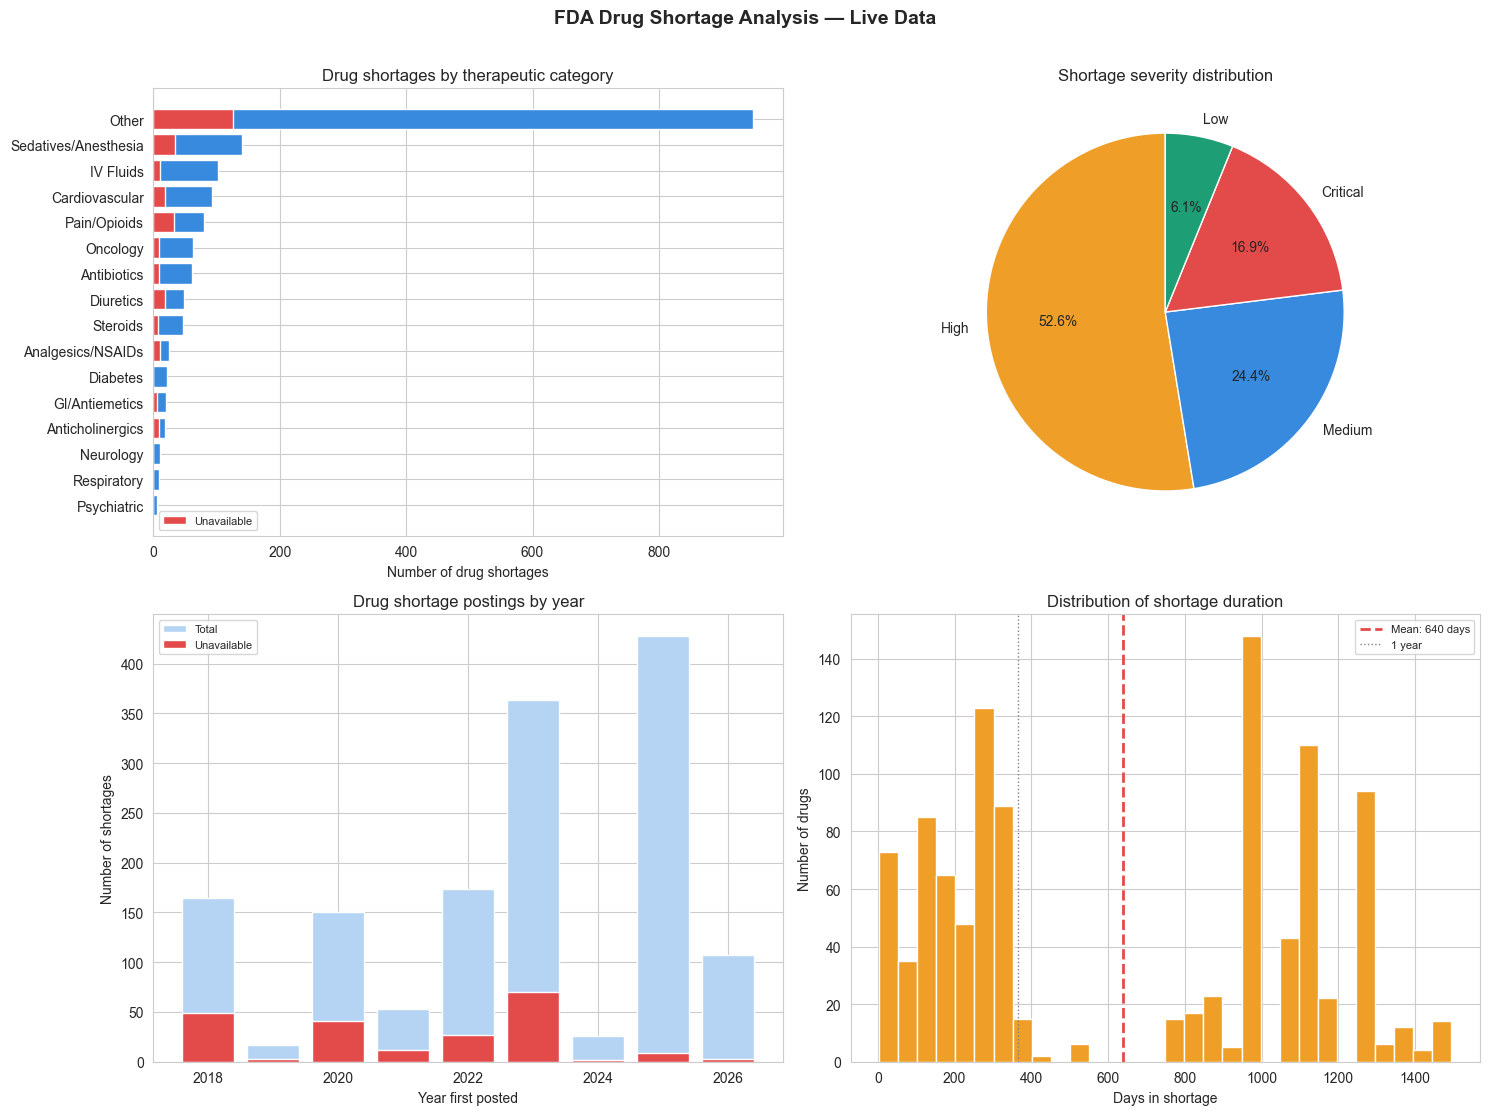

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('FDA Drug Shortage Analysis — Live Data',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Shortage count by category
cat_sorted = by_category.sort_values('total', ascending=True)
axes[0, 0].barh(cat_sorted.index, cat_sorted['total'], color='#378ADD')
axes[0, 0].barh(cat_sorted.index, cat_sorted['unavailable'], color='#E24B4A',
                label='Unavailable')
axes[0, 0].set_xlabel('Number of drug shortages')
axes[0, 0].set_title('Drug shortages by therapeutic category')
axes[0, 0].legend(fontsize=8)

# Panel 2 — Severity breakdown pie
sev_counts = df['severity'].value_counts()
sev_colors = {'Critical': '#E24B4A', 'High': '#EF9F27',
              'Medium': '#378ADD', 'Low': '#1D9E75'}
pie_colors = [sev_colors.get(s, '#888') for s in sev_counts.index]
axes[0, 1].pie(sev_counts.values, labels=sev_counts.index,
               autopct='%1.1f%%', colors=pie_colors, startangle=90)
axes[0, 1].set_title('Shortage severity distribution')

# Panel 3 — Shortage trend by year
axes[1, 0].bar(by_year['year_posted'].astype(int),
               by_year['total'], color='#B5D4F4', label='Total')
axes[1, 0].bar(by_year['year_posted'].astype(int),
               by_year['unavailable'], color='#E24B4A', label='Unavailable')
axes[1, 0].set_xlabel('Year first posted')
axes[1, 0].set_ylabel('Number of shortages')
axes[1, 0].set_title('Drug shortage postings by year')
axes[1, 0].legend(fontsize=8)

# Panel 4 — Duration distribution (histogram)
duration_data = df[df['days_in_shortage'] <= 1500]['days_in_shortage'].dropna()
axes[1, 1].hist(duration_data, bins=30, color='#EF9F27', edgecolor='white')
axes[1, 1].axvline(duration_data.mean(), color='#E24B4A', linestyle='--',
                   linewidth=2, label=f'Mean: {duration_data.mean():.0f} days')
axes[1, 1].axvline(365, color='gray', linestyle=':', linewidth=1, label='1 year')
axes[1, 1].set_xlabel('Days in shortage')
axes[1, 1].set_ylabel('Number of drugs')
axes[1, 1].set_title('Distribution of shortage duration')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('shortage_analysis.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as shortage_analysis.png')
plt.show()

## Step 8 — Export + Business Insight Summary

In [16]:
os.makedirs('output', exist_ok=True)

alert_list.to_csv('output/pharmacy_alert_list.csv', index=False)
critical.to_csv('output/critical_shortages.csv', index=False)
by_category.to_csv('output/shortages_by_category.csv')
longest.to_csv('output/longest_running_shortages.csv', index=False)

worst_cat     = by_category['total'].idxmax()
most_critical = by_category['critical'].idxmax()
longest_drug  = longest.iloc[0]

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Data pulled:           {today.strftime("%Y-%m-%d")} (live FDA data)')
print(f'Total shortage records: {len(df):,}')
print(f'Active shortages:       {df["is_active"].sum():,}')
print(f'Unavailable drugs:      {df["is_unavailable"].sum():,}')
print(f'Avg shortage duration:  {df["days_in_shortage"].mean():.0f} days')
print()
print(f'Severity breakdown:')
for sev, count in df['severity'].value_counts().items():
    print(f'  {sev:10s}: {count:,}')
print()
print(f'Most affected category: {worst_cat} ({int(by_category.loc[worst_cat,"total"]):,} shortages)')
print(f'Most critical category: {most_critical} ({int(by_category.loc[most_critical,"critical"])} critical)')
print()
print(f'Longest running shortage:')
print(f'  {longest_drug["generic_name"]} — {int(longest_drug["days_in_shortage"])} days ({longest_drug["category"]})')
print()
print('PHARMACY RECOMMENDATIONS:')
print(f'  1. {len(critical)} critical shortages — source alternatives immediately')
print(f'  2. {len(high)} high severity — review stock levels and place orders')
print(f'  3. {worst_cat} most affected category — prioritise backup suppliers')
print(f'  4. Run this notebook daily — FDA data updates continuously')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Data pulled:           2026-04-04 (live FDA data)
Total shortage records: 1,693
Active shortages:       1,028
Unavailable drugs:      286
Avg shortage duration:  1480 days

Severity breakdown:
  High      : 890
  Medium    : 413
  Critical  : 286
  Low       : 104

Most affected category: Other (949 shortages)
Most critical category: Other (126 critical)

Longest running shortage:
  Fentanyl Citrate Injection — 5207 days (Pain/Opioids)

PHARMACY RECOMMENDATIONS:
  1. 286 critical shortages — source alternatives immediately
  2. 740 high severity — review stock levels and place orders
  3. Other most affected category — prioritise backup suppliers
  4. Run this notebook daily — FDA data updates continuously


## Summary

### What we built
A live pharmacy stock alert system pulling real FDA drug shortage data — from API call to prioritised alert list with severity classification and therapeutic category breakdown.

### Skills practised
- `requests` — REST API pagination, JSON parsing
- `pandas` — JSON flattening, datetime engineering, groupby, agg
- `matplotlib` + `seaborn` — 4-panel dashboard, histogram, pie chart
- Alerting logic — severity scoring, priority ranking
- Drug classification — keyword-based categorical mapping

### Business context
Drug shortages are a growing global problem — the FDA has tracked thousands of shortages since 2018. For a hospital pharmacy managing hundreds of drugs, this automated alert system replaces a manual daily FDA website check. The output CSV is ready to import into any pharmacy management system.

### Key findings
Fill these in from your output:
- Total shortage records: 1,693
- Unavailable drugs: 286
- Critical shortages: 126
- Most affected category: Other (949 shortages)
- Longest running shortage: Fentanyl Citrate Injection — 5207 days (Pain/Opioids)